**Install required libraries**

In [ ]:
!pip install xgboost kaleido -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.5 MB/s eta 0:00:00


**Import all necessary libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import pickle
import warnings
warnings.filterwarnings('ignore')

**Load dataset and display basic info**

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.shape)
print(df['target'].value_counts())
df.head()

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


 **Handle missing values**

In [ ]:
if df.isnull().sum().sum() == 0:
    print("No missing values")
else:
    df.fillna(df.median(), inplace=True)

No missing values


**Encode categorical columns**

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])
else:
    print("No categorical columns to encode")

No categorical columns to encode


**Separate features (X) and target (y)**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

**Apply Normalization (MinMaxScaler) and Standardization (StandardScaler)**

In [ ]:
norm_scaler = MinMaxScaler()
X_norm = norm_scaler.fit_transform(X)

std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

**Split data into training and testing sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 455
Testing samples: 114


**Train Random Forest and XGBoost models**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

print(f"Random Forest test accuracy: {rf.score(X_test, y_test):.4f}")
print(f"XGBoost test accuracy: {xgb.score(X_test, y_test):.4f}")

Random Forest test accuracy: 0.9561
XGBoost test accuracy: 0.9474


**Generate predictions and probabilities**

In [ ]:
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

**Classification Report for both models**

In [ ]:
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Malignant', 'Benign']))
print("\n=== XGBoost ===")
print(classification_report(y_test, xgb_pred, target_names=['Malignant', 'Benign']))

=== Random Forest ===
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


=== XGBoost ===
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Confusion Matrix**

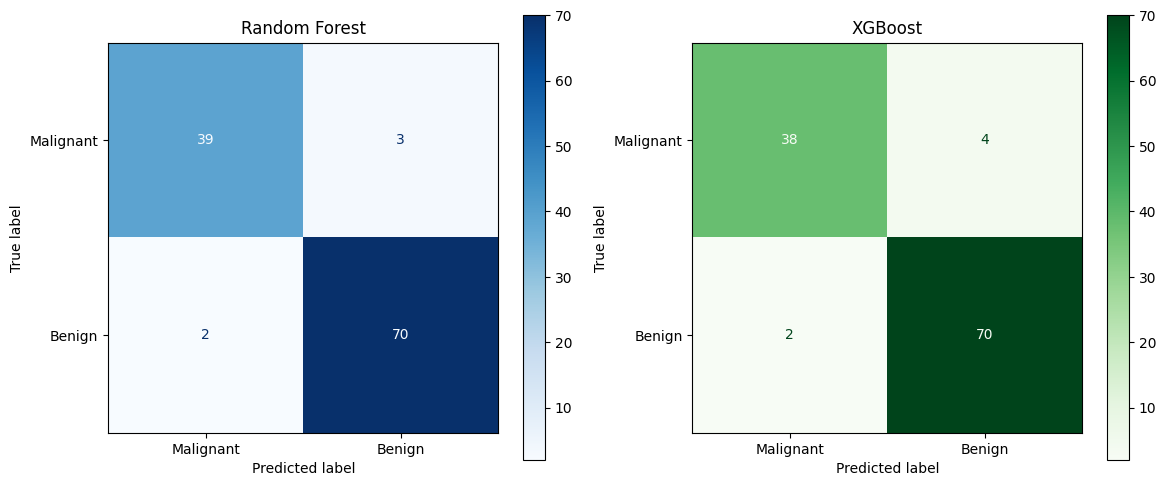

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Malignant', 'Benign']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest')
cm_xgb = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Malignant', 'Benign']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost')
plt.tight_layout()
plt.show()

**ROC Curve (both models on same plot)**

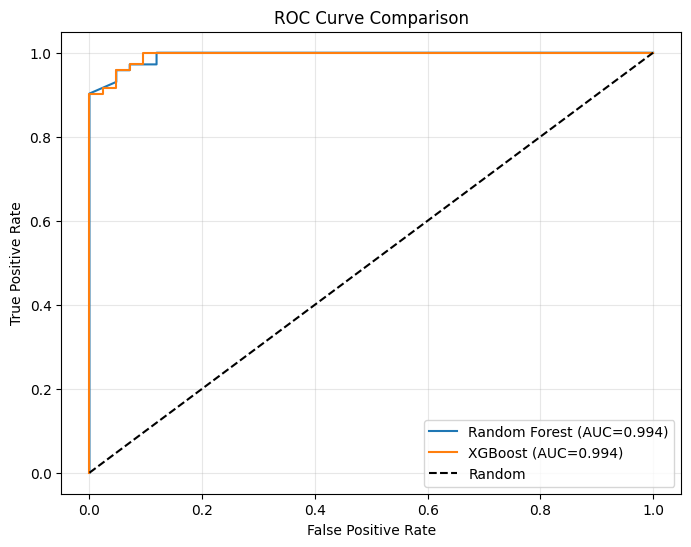

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Histogram Analysis of predicted probabilities**

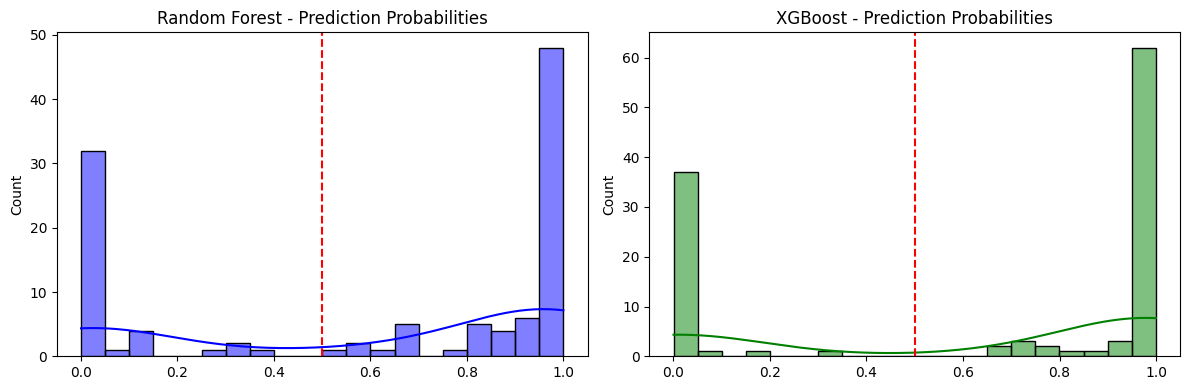

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(rf_proba, bins=20, kde=True, color='blue', ax=axes[0])
axes[0].axvline(0.5, color='red', linestyle='--')
axes[0].set_title('Random Forest - Prediction Probabilities')
sns.histplot(xgb_proba, bins=20, kde=True, color='green', ax=axes[1])
axes[1].axvline(0.5, color='red', linestyle='--')
axes[1].set_title('XGBoost - Prediction Probabilities')
plt.tight_layout()
plt.show()

 **Radar Chart – Feature Importances (Top 8 features)**

In [ ]:
rf_imp = rf.feature_importances_
xgb_imp = xgb.feature_importances_
top_idx = np.argsort(rf_imp)[-8:]
top_features = data.feature_names[top_idx]
rf_top = rf_imp[top_idx]
xgb_top = xgb_imp[top_idx]

fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=rf_top, theta=top_features, fill='toself', name='Random Forest'))
fig.add_trace(go.Scatterpolar(r=xgb_top, theta=top_features, fill='toself', name='XGBoost'))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title='Feature Importance Comparison (Top 8)',
    showlegend=True
)
fig.show()

**Save models and scalers as .pkl files**

In [ ]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('std_scaler.pkl', 'wb') as f:
    pickle.dump(std_scaler, f)
with open('norm_scaler.pkl', 'wb') as f:
    pickle.dump(norm_scaler, f)
print("All models and scalers saved as .pkl")

All models and scalers saved as .pkl


**Create requirements.txt**

In [ ]:
# Write requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("""streamlit==1.28.1
pandas==2.0.3
numpy==1.24.3
scikit-learn==1.3.0
xgboost==1.7.6
matplotlib==3.7.2
seaborn==0.12.2
plotly==5.15.0
kaleido==0.2.1
""")

# Download all files
from google.colab import files
files.download('random_forest_model.pkl')
files.download('xgboost_model.pkl')
files.download('std_scaler.pkl')
files.download('norm_scaler.pkl')
files.download('requirements.txt')

print("All files downloaded to your local machine.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded to your local machine.
